# CPU Usage Forecasting with CatBoost (Stratified Split)
Прогнозирование загрузки CPU на 2-3 минуты с правильным разбиением данных (чистый датасет)

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/cpu_dataset.csv')
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nCPU stats:\n{df['cpu_usage_percent'].describe()}")

Shape: (24329, 2)

Columns: ['timestamp', 'cpu_usage_percent']

CPU stats:
count    24329.000000
mean        51.849760
std         21.706086
min         18.552542
25%         24.443220
50%         54.753083
75%         69.650000
max         99.616102
Name: cpu_usage_percent, dtype: float64


In [35]:
# 2-3 minutes = 8-12 points (at 15-second intervals)
FORECAST_HORIZON = 10  # 10 * 15 sec = 2.5 minutes

# Create lagged features
def create_features(df, horizon=FORECAST_HORIZON, lags=[1, 2, 3, 4, 5, 8, 12, 16, 20]):
    df = df.copy()
    
    # Lag features
    for lag in lags:
        df[f'cpu_lag_{lag}'] = df['cpu_usage_percent'].shift(lag)
    
    # Rolling statistics (short-term patterns)
    for window in [4, 8, 12]:
        df[f'cpu_rolling_mean_{window}'] = df['cpu_usage_percent'].rolling(window).mean()
        df[f'cpu_rolling_std_{window}'] = df['cpu_usage_percent'].rolling(window).std()
        df[f'cpu_rolling_min_{window}'] = df['cpu_usage_percent'].rolling(window).min()
        df[f'cpu_rolling_max_{window}'] = df['cpu_usage_percent'].rolling(window).max()
    
    # Target: CPU value in FORECAST_HORIZON steps
    df['cpu_target'] = df['cpu_usage_percent'].shift(-horizon)
    
    return df

df_features = create_features(df, horizon=FORECAST_HORIZON)
print(f"Features created. Shape: {df_features.shape}")

Features created. Shape: (24329, 24)


In [36]:
# Remove rows with NaN values
df_clean = df_features.dropna().reset_index(drop=True)
print(f"After removing NaN: {df_clean.shape}")
print(f"Removed {df_features.shape[0] - df_clean.shape[0]} rows")

# Extract hour from timestamp for stratified split
df_clean['hour'] = pd.to_datetime(df_clean['timestamp'], unit='s').dt.hour

# Stratified train/test split by hour
# For each hour, split 80/20 by time (to preserve temporal order)
hours = df_clean['hour'].unique()
train_dfs = []
test_dfs = []

print(f"\n🎯 Stratified split by hour:")
print(f"{'Hour':>6} {'Total':>8} {'Train':>8} {'Test':>8}")
print("-" * 40)

for hour in sorted(hours):
    hour_data = df_clean[df_clean['hour'] == hour].reset_index(drop=True)
    split_idx = int(len(hour_data) * 0.8)
    
    train_dfs.append(hour_data[:split_idx])
    test_dfs.append(hour_data[split_idx:])
    
    print(f"{hour:>6} {len(hour_data):>8} {split_idx:>8} {len(hour_data)-split_idx:>8}")

# Combine all hours
df_train = pd.concat(train_dfs, ignore_index=True).sort_values('timestamp').reset_index(drop=True)
df_test = pd.concat(test_dfs, ignore_index=True).sort_values('timestamp').reset_index(drop=True)

print("-" * 40)
print(f"{'TOTAL':>6} {len(df_clean):>8} {len(df_train):>8} {len(df_test):>8}")
print(f"Split ratio: {len(df_train)/len(df_clean)*100:.1f}% / {len(df_test)/len(df_clean)*100:.1f}%")

After removing NaN: (24299, 24)
Removed 30 rows

🎯 Stratified split by hour:
  Hour    Total    Train     Test
----------------------------------------
     0      964      771      193
     1      960      768      192
     2      960      768      192
     3      960      768      192
     4      960      768      192
     5      960      768      192
     6      964      771      193
     7      960      768      192
     8      960      768      192
     9      960      768      192
    10      960      768      192
    11      960      768      192
    12      964      771      193
    13      960      768      192
    14      960      768      192
    15      960      768      192
    16      960      768      192
    17      960      768      192
    18     1016      812      204
    19     1200      960      240
    20     1200      960      240
    21     1200      960      240
    22     1200      960      240
    23     1191      952      239
--------------------------------

In [37]:
# Feature selection (only CPU lags and rolling stats)
lag_features = [col for col in df_clean.columns if 'cpu_lag' in col or 'cpu_rolling' in col]
feature_cols = lag_features

X_train = df_train[feature_cols]
y_train = df_train['cpu_target']

X_test = df_test[feature_cols]
y_test = df_test['cpu_target']

print(f"Features: {len(feature_cols)}")
print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Features: 21
Train set: (19437, 21)
Test set: (4862, 21)


In [38]:
# Detailed analysis of stratified splits
print("\n" + "="*80)
print("DETAILED ANALYSIS OF STRATIFIED TRAIN/TEST DATA SPLITS")
print("="*80)

print("\n📊 SIZE COMPARISON:")
print(f"  Train size: {len(df_train):,} samples ({len(df_train)/len(df_clean)*100:.1f}%)")
print(f"  Test size:  {len(df_test):,} samples ({len(df_test)/len(df_clean)*100:.1f}%)")

print("\n⏰ TEMPORAL COVERAGE:")
from datetime import datetime
train_start = datetime.fromtimestamp(df_train['timestamp'].min())
train_end = datetime.fromtimestamp(df_train['timestamp'].max())
test_start = datetime.fromtimestamp(df_test['timestamp'].min())
test_end = datetime.fromtimestamp(df_test['timestamp'].max())

print(f"  Train: {train_start} → {train_end}")
print(f"         ({(train_end - train_start).total_seconds()/3600:.1f} hours)")
print(f"  Test:  {test_start} → {test_end}")
print(f"         ({(test_end - test_start).total_seconds()/3600:.1f} hours)")

print("\n📈 CPU USAGE STATISTICS:")
print(f"  {'':20} {'Train':>12} {'Test':>12} {'Diff':>12}")
train_mean = df_train['cpu_usage_percent'].mean()
test_mean = df_test['cpu_usage_percent'].mean()
print(f"  {'Mean':20} {train_mean:>12.2f}% {test_mean:>12.2f}% {test_mean-train_mean:>+12.2f}%")
print(f"  {'Median':20} {df_train['cpu_usage_percent'].median():>12.2f}% {df_test['cpu_usage_percent'].median():>12.2f}%")
print(f"  {'Min':20} {df_train['cpu_usage_percent'].min():>12.2f}% {df_test['cpu_usage_percent'].min():>12.2f}%")
print(f"  {'Max':20} {df_train['cpu_usage_percent'].max():>12.2f}% {df_test['cpu_usage_percent'].max():>12.2f}%")
print(f"  {'Std Dev':20} {df_train['cpu_usage_percent'].std():>12.2f}% {df_test['cpu_usage_percent'].std():>12.2f}%")

print("\n🏷️  HOUR DISTRIBUTION:")
print(f"{'Hour':>6} {'Train':>10} {'Test':>10} {'Train %':>10} {'Test %':>10}")
for hour in sorted(df_clean['hour'].unique()):
    train_count = len(df_train[df_train['hour'] == hour])
    test_count = len(df_test[df_test['hour'] == hour])
    train_pct = train_count / len(df_train) * 100 if len(df_train) > 0 else 0
    test_pct = test_count / len(df_test) * 100 if len(df_test) > 0 else 0
    print(f"{hour:>6} {train_count:>10,} {test_count:>10,} {train_pct:>10.1f}% {test_pct:>10.1f}%")

print("\n" + "="*80)


DETAILED ANALYSIS OF STRATIFIED TRAIN/TEST DATA SPLITS

📊 SIZE COMPARISON:
  Train size: 19,437 samples (80.0%)
  Test size:  4,862 samples (20.0%)

⏰ TEMPORAL COVERAGE:
  Train: 2026-05-25 21:47:00 → 2026-05-29 21:09:00
         (95.4 hours)
  Test:  2026-05-29 02:58:00 → 2026-05-30 02:57:30
         (24.0 hours)

📈 CPU USAGE STATISTICS:
                              Train         Test         Diff
  Mean                        51.61%        52.98%        +1.37%
  Median                      55.37%        52.67%
  Min                         18.55%        20.14%
  Max                         99.62%        90.51%
  Std Dev                     21.68%        21.71%

🏷️  HOUR DISTRIBUTION:
  Hour      Train       Test    Train %     Test %
     0        771        193        4.0%        4.0%
     1        768        192        4.0%        3.9%
     2        768        192        4.0%        3.9%
     3        768        192        4.0%        3.9%
     4        768        192        4.0%

In [39]:
# Train CatBoost model
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function='MAE',
    eval_metric='MAE',
    verbose=100,
    random_state=42,
    task_type='CPU'
)

model.fit(train_pool, eval_set=test_pool)

0:	learn: 17.6917783	test: 17.9001472	best: 17.9001472 (0)	total: 7.56ms	remaining: 3.77s
100:	learn: 1.3044244	test: 1.3448038	best: 1.3448038 (100)	total: 281ms	remaining: 1.11s
200:	learn: 1.0793765	test: 1.1357243	best: 1.1357243 (200)	total: 608ms	remaining: 905ms
300:	learn: 0.9814940	test: 1.0742471	best: 1.0742471 (300)	total: 866ms	remaining: 572ms
400:	learn: 0.9100048	test: 1.0355830	best: 1.0355830 (400)	total: 1.14s	remaining: 281ms
499:	learn: 0.8657457	test: 1.0167545	best: 1.0167545 (499)	total: 1.53s	remaining: 0us

bestTest = 1.016754528
bestIteration = 499



CatBoostRegressor(depth=7, eval_metric='MAE', iterations=500, learning_rate=0.05, loss_function='MAE', random_state=42, task_type='CPU', verbose=100)

In [40]:
# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluate
def evaluate(y_true, y_pred, set_name=''):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    print(f"{set_name}")
    print(f"  MAE:  {mae:.3f}%")
    print(f"  RMSE: {rmse:.3f}%")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R²:   {r2:.4f}")
    return mae, rmse, mape, r2

print("="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
train_metrics = evaluate(y_train, y_pred_train, '📊 Train Set')
print()
test_metrics = evaluate(y_test, y_pred_test, '📊 Test Set')
print("="*50)

# Check for overfitting/underfitting
print("\n🔍 Analysis:")
mae_diff = test_metrics[0] - train_metrics[0]
if abs(mae_diff) < 0.2:
    print(f"  ✓ Excellent generalization! (MAE difference: {mae_diff:+.3f}%)")
elif abs(mae_diff) < 0.5:
    print(f"  ✓ Good generalization (MAE difference: {mae_diff:+.3f}%)")
elif mae_diff > 0.5:
    print(f"  ⚠ Slight overfitting (MAE difference: {mae_diff:+.3f}%)")
else:
    print(f"  ⚠ Test better than train? (MAE diff: {mae_diff:+.3f}%)")

MODEL PERFORMANCE METRICS
📊 Train Set
  MAE:  0.866%
  RMSE: 1.587%
  MAPE: 1.71%
  R²:   0.9946

📊 Test Set
  MAE:  1.017%
  RMSE: 1.754%
  MAPE: 1.99%
  R²:   0.9935

🔍 Analysis:
  ✓ Excellent generalization! (MAE difference: +0.151%)


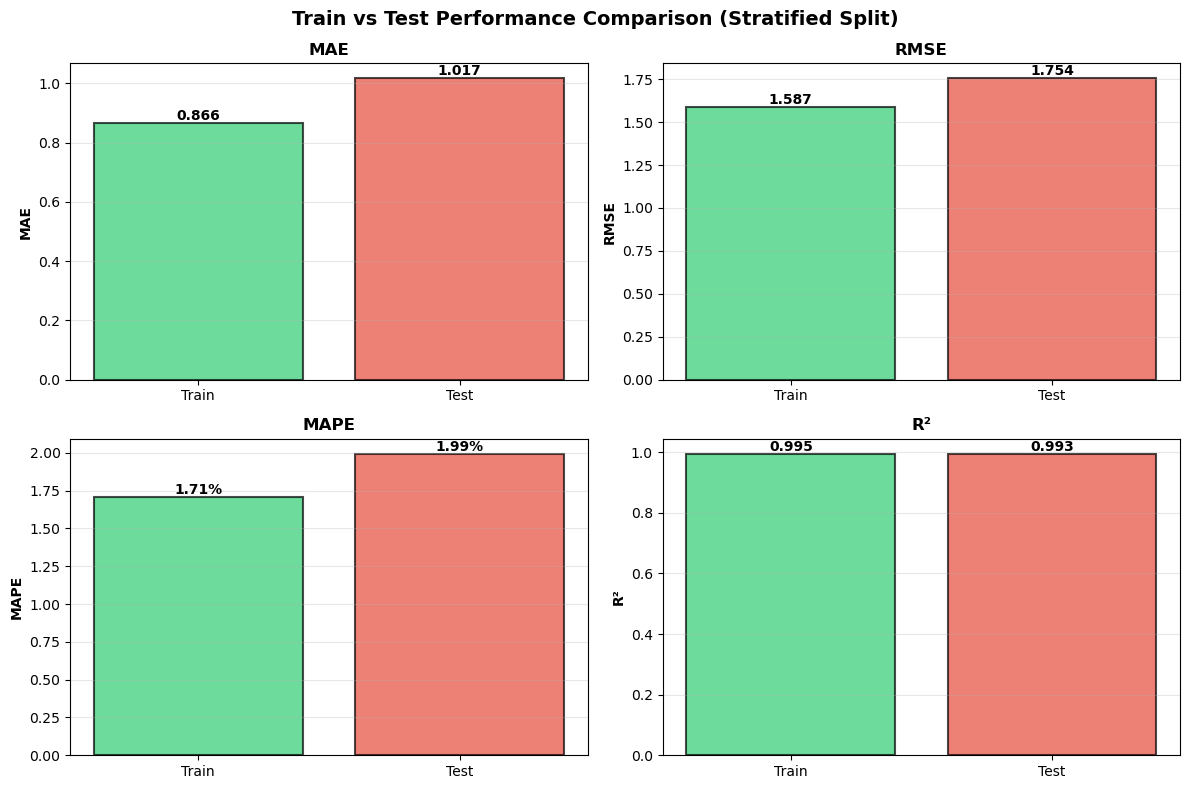


METRICS COMPARISON TABLE
Metric                    Train            Test      Difference
----------------------------------------------------------------------
MAE (%)                  0.8657          1.0168         +0.1510
RMSE (%)                 1.5875          1.7542         +0.1667
MAPE (%)                 1.7107          1.9932         +0.2825
R²                       0.9946          0.9935         -0.0011


In [41]:
# Comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Train vs Test Performance Comparison (Stratified Split)', fontsize=14, fontweight='bold')

metrics = {
    'MAE': (train_metrics[0], test_metrics[0]),
    'RMSE': (train_metrics[1], test_metrics[1]),
    'MAPE': (train_metrics[2], test_metrics[2]),
    'R²': (train_metrics[3], test_metrics[3])
}

positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
colors = ['#2ecc71', '#e74c3c']

for (metric_name, (train_val, test_val)), (i, j) in zip(metrics.items(), positions):
    ax = axes[i, j]
    bars = ax.bar(['Train', 'Test'], [train_val, test_val], color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric_name, fontweight='bold')
    ax.set_title(f'{metric_name}', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}' if metric_name != 'MAPE' else f'{height:.2f}%',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("METRICS COMPARISON TABLE")
print("="*70)
print(f"{'Metric':<15} {'Train':>15} {'Test':>15} {'Difference':>15}")
print("-"*70)
print(f"{'MAE (%)':15} {train_metrics[0]:>15.4f} {test_metrics[0]:>15.4f} {test_metrics[0]-train_metrics[0]:>+15.4f}")
print(f"{'RMSE (%)':15} {train_metrics[1]:>15.4f} {test_metrics[1]:>15.4f} {test_metrics[1]-train_metrics[1]:>+15.4f}")
print(f"{'MAPE (%)':15} {train_metrics[2]:>15.4f} {test_metrics[2]:>15.4f} {test_metrics[2]-train_metrics[2]:>+15.4f}")
print(f"{'R²':15} {train_metrics[3]:>15.4f} {test_metrics[3]:>15.4f} {test_metrics[3]-train_metrics[3]:>+15.4f}")
print("="*70)


Top 15 Important Features:
            feature  importance
  cpu_rolling_min_8   13.400740
          cpu_lag_4   11.598084
 cpu_rolling_max_12    8.391830
  cpu_rolling_max_8    7.502025
 cpu_rolling_mean_8    5.019247
 cpu_rolling_min_12    4.797323
 cpu_rolling_std_12    4.748630
cpu_rolling_mean_12    4.500561
  cpu_rolling_max_4    4.335377
          cpu_lag_5    4.280055
          cpu_lag_2    4.121358
 cpu_rolling_mean_4    4.073292
  cpu_rolling_min_4    4.060513
         cpu_lag_20    3.682589
          cpu_lag_1    3.182850


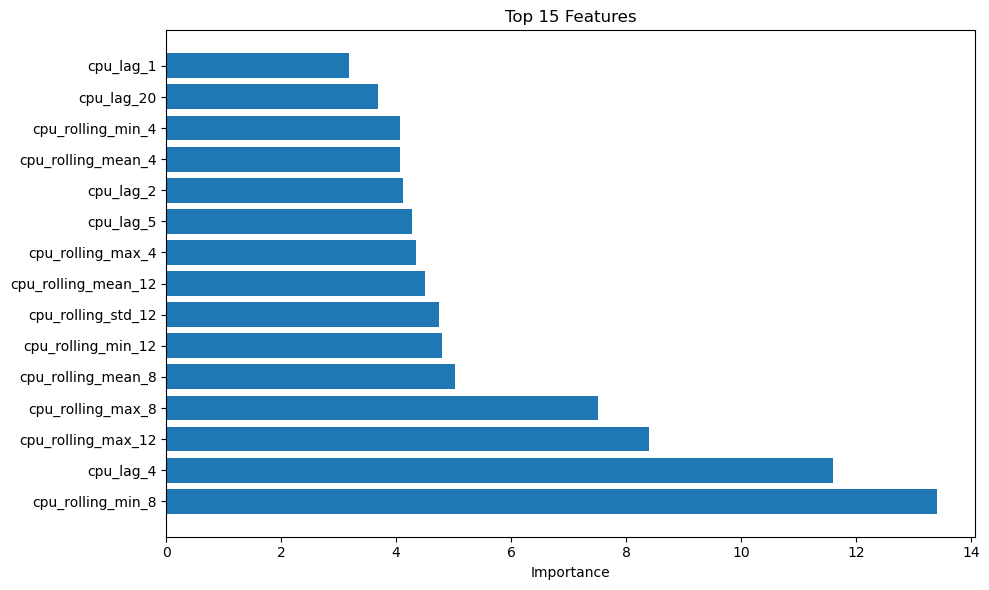

In [42]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False)

print("\nTop 15 Important Features:")
print(feature_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Features')
plt.tight_layout()
plt.show()

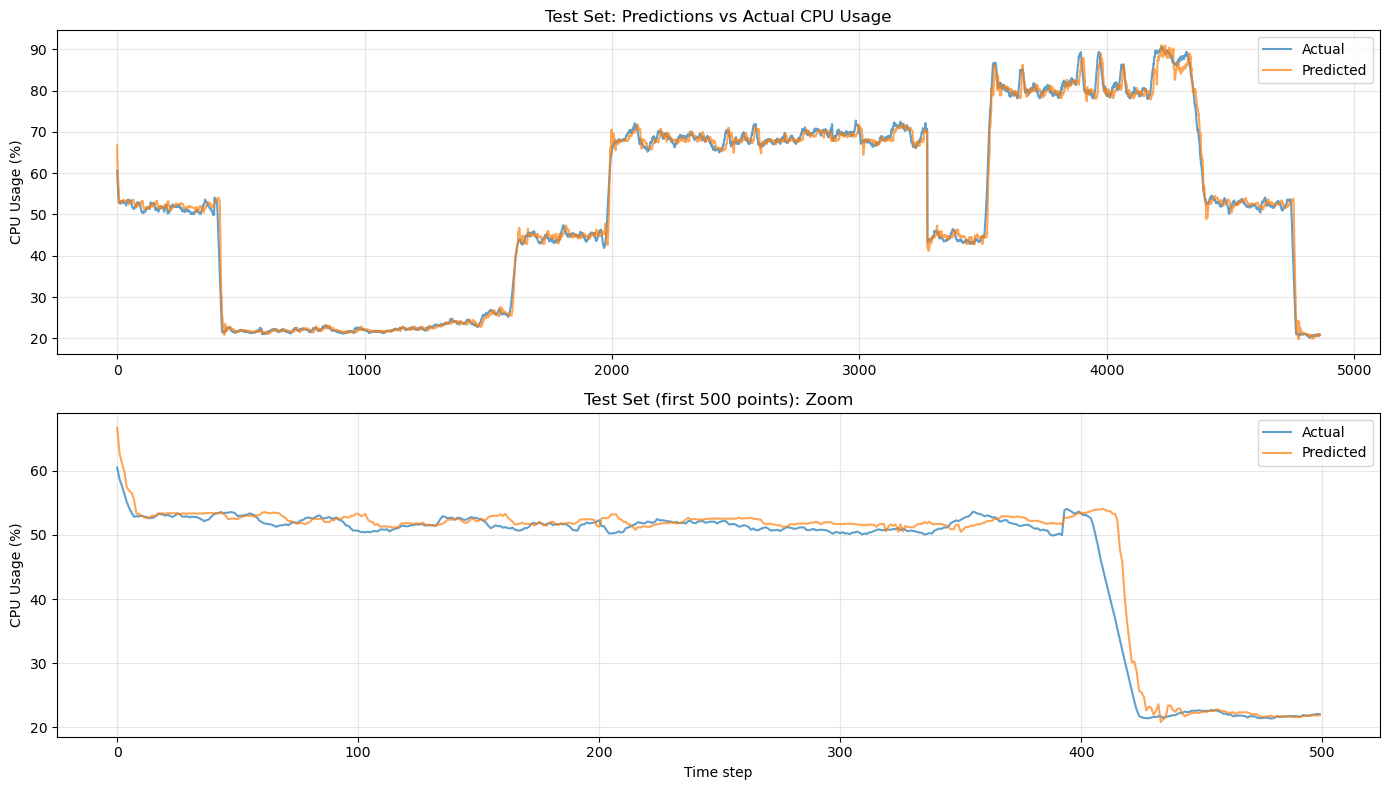


Prediction error distribution (test set):
  Min error: 0.001%
  Median error: 0.608%
  Max error: 17.018%
  95th percentile: 3.304%


In [43]:
# Visualization: predictions vs actual
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

test_range = range(len(y_test))
axes[0].plot(test_range, y_test.values, label='Actual', alpha=0.7, linewidth=1.5)
axes[0].plot(test_range, y_pred_test, label='Predicted', alpha=0.7, linewidth=1.5)
axes[0].set_title('Test Set: Predictions vs Actual CPU Usage')
axes[0].set_ylabel('CPU Usage (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

zoom_range = range(min(500, len(y_test)))
axes[1].plot(zoom_range, y_test.values[:500], label='Actual', alpha=0.7, linewidth=1.5)
axes[1].plot(zoom_range, y_pred_test[:500], label='Predicted', alpha=0.7, linewidth=1.5)
axes[1].set_title('Test Set (first 500 points): Zoom')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('CPU Usage (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPrediction error distribution (test set):")
errors = np.abs(y_test.values - y_pred_test)
print(f"  Min error: {errors.min():.3f}%")
print(f"  Median error: {np.median(errors):.3f}%")
print(f"  Max error: {errors.max():.3f}%")
print(f"  95th percentile: {np.percentile(errors, 95):.3f}%")

In [44]:
# Save model
model.save_model('../models/cpu_forecast_model.cbm')
print("Model saved as 'cpu_forecast_model.cbm'")

import json
with open('../models/cpu_model_config.json', 'w') as f:
    json.dump({
        'feature_cols': feature_cols,
        'forecast_horizon': FORECAST_HORIZON,
        'lag_features': [1, 2, 3, 4, 5, 8, 12, 16, 20],
        'rolling_windows': [4, 8, 12]
    }, f, indent=2)
print("Config saved as 'cpu_model_config.json'")

Model saved as 'cpu_forecast_model.cbm'
Config saved as 'cpu_model_config.json'
